In [1]:
import os, warnings, re
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import issparse, csr_matrix
from collections import defaultdict

warnings.filterwarnings("ignore")
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False)
sns.set_style("ticks")

DATA = "/mnt/172/wh/25-12/spatial/raw/SPAC-seq/MC38_tumor"
OUT_DIR = "/root/code/nicheformer/output/0527"
os.makedirs(OUT_DIR, exist_ok=True)

LIBS = ["libHD274E6", "libHD275E7", "libHD276E8", "libHD277E9"]

print("SPAC-seq: MC38 tumor — Spatial Perturbation Assay (in vivo CRISPR in mouse colon cancer)")
print("=" * 70)


SPAC-seq: MC38 tumor — Spatial Perturbation Assay (in vivo CRISPR in mouse colon cancer)


In [4]:
adatas['libHD274E6'].obs

,in_tissue,array_row,array_col,guide,target_gene,guide_count,library
s_008um_00172_00448-1,1,172,448,none,none,0,libHD274E6
s_008um_00239_00812-1,1,239,812,none,none,0,libHD274E6
s_008um_00269_00526-1,1,269,526,none,none,0,libHD274E6
s_008um_00693_00628-1,1,693,628,none,none,0,libHD274E6
s_008um_00260_00253-1,1,260,253,none,none,0,libHD274E6
...,...,...,...,...,...,...,...
s_008um_00610_00321-1,1,610,321,none,none,0,libHD274E6
s_008um_00003_00520-1,1,3,520,none,none,0,libHD274E6
s_008um_00247_00283-1,1,247,283,none,none,0,libHD274E6
s_008um_00708_00481-1,1,708,481,none,none,0,libHD274E6


In [5]:
adata_t

AnnData object with n_obs × n_vars = 454825 × 19059
    obs: 'in_tissue', 'array_row', 'array_col', 'guide', 'target_gene', 'guide_count', 'library'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'

In [6]:
adata_p

AnnData object with n_obs × n_vars = 454825 × 1520
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'

In [7]:
adata_p.var

,gene_ids,feature_types,genome
sgTgfbr2_1,sgTgfbr2_1,Gene Expression,geneEx-mm10-tumor-1520-scaffold
sgTgfbr2_2,sgTgfbr2_2,Gene Expression,geneEx-mm10-tumor-1520-scaffold
sgIl17re_1,sgIl17re_1,Gene Expression,geneEx-mm10-tumor-1520-scaffold
sgIl17re_2,sgIl17re_2,Gene Expression,geneEx-mm10-tumor-1520-scaffold
sgIl17rc_1,sgIl17rc_1,Gene Expression,geneEx-mm10-tumor-1520-scaffold
...,...,...,...
sgnon-targeting_46,sgnon-targeting_46,Gene Expression,geneEx-mm10-tumor-1520-scaffold
sgnon-targeting_47,sgnon-targeting_47,Gene Expression,geneEx-mm10-tumor-1520-scaffold
sgnon-targeting_48,sgnon-targeting_48,Gene Expression,geneEx-mm10-tumor-1520-scaffold
sgnon-targeting_49,sgnon-targeting_49,Gene Expression,geneEx-mm10-tumor-1520-scaffold


In [8]:
adata_p.obs

,in_tissue,array_row,array_col
s_008um_00269_00526-1,1,269,526
s_008um_00547_00611-1,1,547,611
s_008um_00260_00253-1,1,260,253
s_008um_00129_00000-1,1,129,0
s_008um_00433_00599-1,1,433,599
...,...,...,...
s_008um_00307_00022-1,1,307,22
s_008um_00630_00099-1,1,630,99
s_008um_00807_00122-1,1,807,122
s_008um_00247_00283-1,1,247,283


In [10]:
adata_p.X.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [14]:
import h5py
adata_f = h5py.File("/mnt/172/wh/25-12/spatial/raw/SPAC-seq/MC38_tumor/filtered_feature_bc_matrix.h5")
adata_f

<HDF5 file "filtered_feature_bc_matrix.h5" (mode r)>

In [19]:
adata_f["/matrix"].keys()

<KeysViewHDF5 ['barcodes', 'data', 'features', 'indices', 'indptr', 'shape']>

In [22]:
adata_f["/matrix"]['barcodes'][:]

array([b's_008um_00172_00448-1', b's_008um_00239_00812-1',
       b's_008um_00269_00526-1', ..., b's_008um_00247_00283-1',
       b's_008um_00708_00481-1', b's_008um_00414_00651-1'], dtype='|S21')

In [23]:
adata_f["/matrix"]['shape'][:]

array([ 20579, 453638], dtype=int32)

In [3]:
# Load all 4 libraries, merge transcriptome + perturbation
adatas = {}
pert_stats = []

for lib in LIBS:
    print(f"Loading {lib} ...")
    t_path = f"{DATA}/Transcriptome/{lib}_filtered_gene_bc_matrix.h5"
    p_path = f"{DATA}/Perturbation/{lib}_filtered_guide_bc_matrix.h5"

    adata_t = sc.read_h5ad(t_path)  # transcriptome
    adata_p = sc.read_h5ad(p_path)  # perturbation guides

    # Fix: make var_names unique (they have duplicates)
    adata_t.var_names_make_unique()
    adata_p.var_names_make_unique()

    # Extract guide assignment per spot
    p_X = adata_p.X
    if issparse(p_X): p_X = p_X.tocsr()
    guide_counts_per_spot = np.array(p_X.sum(axis=1)).flatten()
    has_guide = guide_counts_per_spot > 0

    # For spots with guides, find the dominant guide
    guide_names = list(adata_p.var_names)
    dominant_guide = np.full(adata_p.n_obs, "none", dtype=object)
    dominant_gene = np.full(adata_p.n_obs, "none", dtype=object)
    guide_count = np.zeros(adata_p.n_obs, dtype=int)

    for i in range(adata_p.n_obs):
        if has_guide[i]:
            row = p_X[i].toarray().flatten()
            top_idx = np.argmax(row)
            guide_count[i] = int(row[top_idx])
            dominant_guide[i] = guide_names[top_idx]
            # Extract gene target from guide name (sgGene_N → Gene)
            gname = guide_names[top_idx]
            if gname.startswith("sgnon-targeting"):
                dominant_gene[i] = "non-targeting"
            elif gname.startswith("sg"):
                gene_part = gname[2:].rsplit("_", 1)[0]  # remove trailing _N
                dominant_gene[i] = gene_part

    # Add to transcriptome obs
    adata_t.obs["guide"] = dominant_guide
    adata_t.obs["target_gene"] = dominant_gene
    adata_t.obs["guide_count"] = guide_count
    adata_t.obs["library"] = lib

    adatas[lib] = adata_t

    n_pert = int(has_guide.sum())
    n_genes_targeted = len(set(dominant_gene[has_guide]) - {"none", "non-targeting"})
    pert_stats.append({
        "Library": lib, "Spots": adata_t.n_obs, "Genes": adata_t.n_vars,
        "Perturbed": n_pert, "Pct": 100 * n_pert / adata_t.n_obs,
        "Targets": n_genes_targeted,
    })

    print(f"  {adata_t.n_obs:,} spots, {n_pert} perturbed ({100*n_pert/adata_t.n_obs:.1f}%)")

df_stats = pd.DataFrame(pert_stats)
print("\\n=== Library overview ===")
print(df_stats.to_string(index=False))


Loading libHD274E6 ...
  453,638 spots, 15443 perturbed (3.4%)
Loading libHD275E7 ...
  356,519 spots, 6239 perturbed (1.7%)
Loading libHD276E8 ...
  304,478 spots, 14271 perturbed (4.7%)
Loading libHD277E9 ...
  454,825 spots, 20069 perturbed (4.4%)
\n=== Library overview ===
   Library  Spots  Genes  Perturbed      Pct  Targets
libHD274E6 453638  19059      15443 3.404256      271
libHD275E7 356519  19059       6239 1.749977      217
libHD276E8 304478  19059      14271 4.687038      276
libHD277E9 454825  19059      20069 4.412466      324


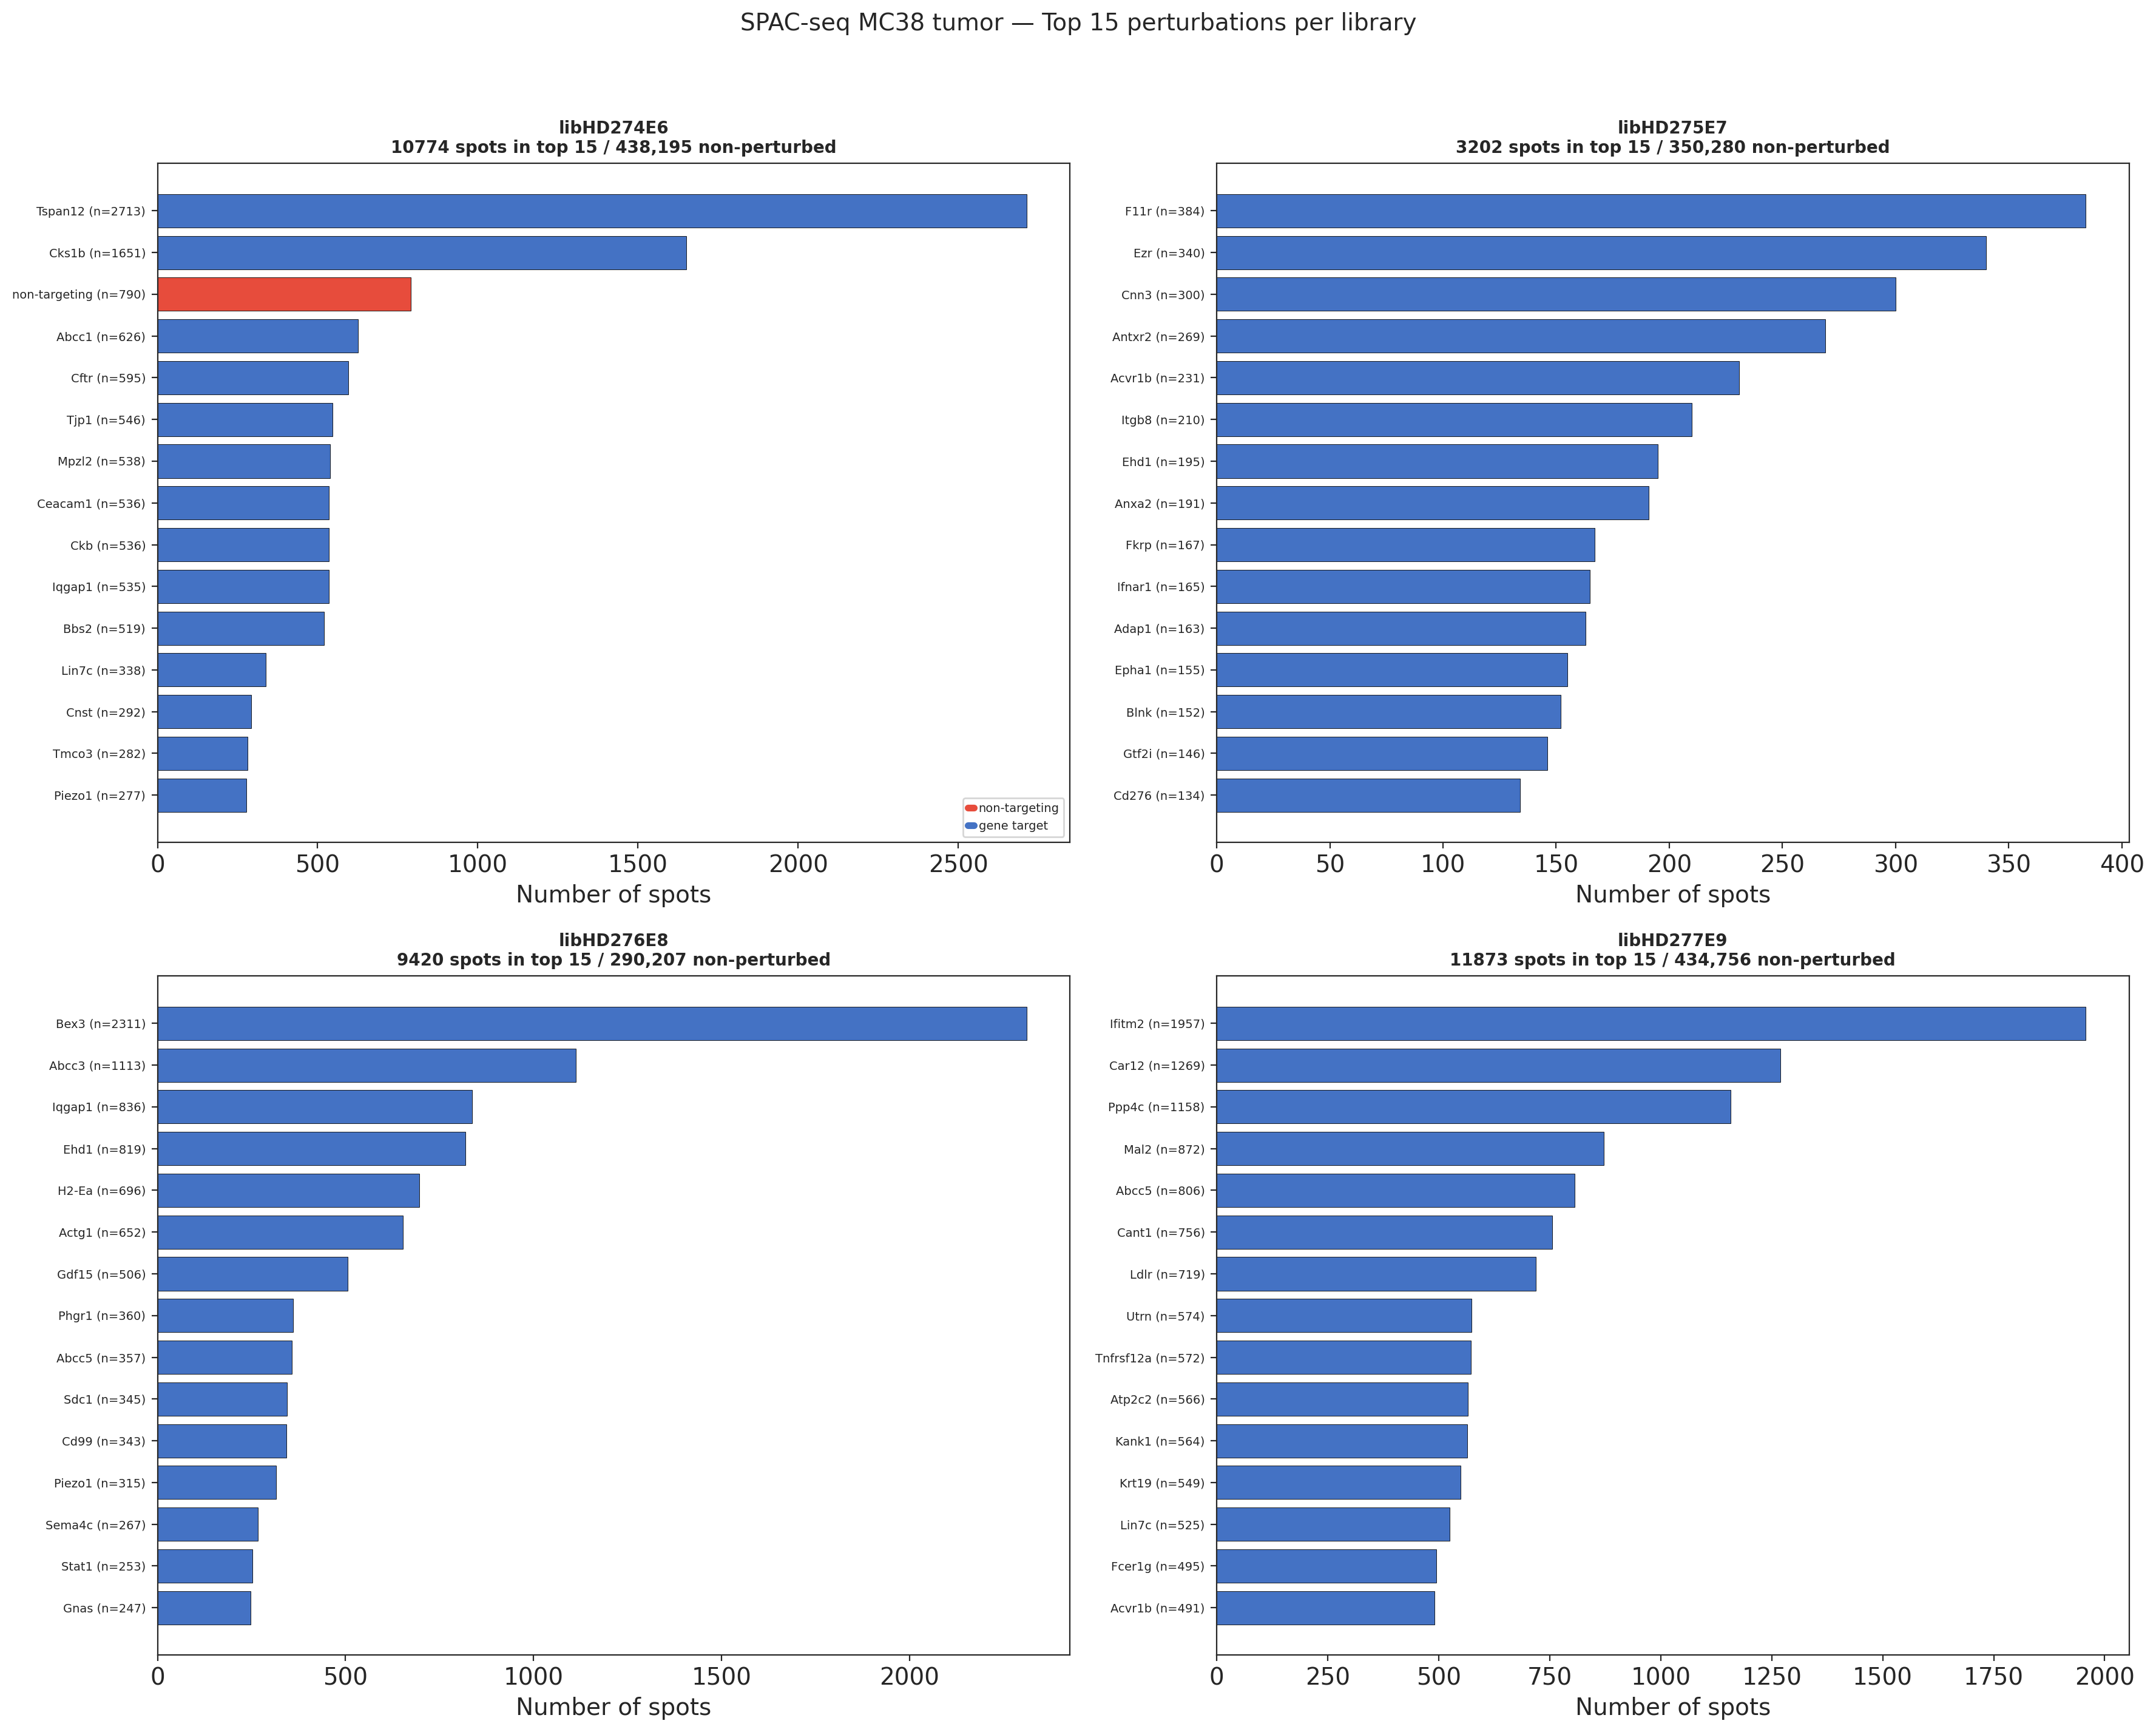

-> spacseq_top_perturbations.png


In [4]:
# Per-library perturbation composition
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, (lib, adata) in enumerate(adatas.items()):
    ax = axes[i]
    vc = adata.obs["target_gene"].value_counts()
    top = vc[vc.index != "none"].head(15)

    colors = ["#E74C3C" if g == "non-targeting" else "#4472C4" for g in top.index]
    bars = ax.barh(range(len(top)), top.values, color=colors, edgecolor="black", linewidth=0.3)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels([f"{g} (n={v})" for g, v in zip(top.index, top.values)], fontsize=7)
    ax.set_xlabel("Number of spots")
    ax.set_title(f"{lib}\n{top.sum()} spots in top 15 / {vc.get('none', 0):,} non-perturbed",
                 fontsize=10, fontweight="bold")
    ax.invert_yaxis()
    if "non-targeting" in top.index:
        ax.legend(handles=[
            plt.Line2D([0],[0],color="#E74C3C",lw=4,label="non-targeting"),
            plt.Line2D([0],[0],color="#4472C4",lw=4,label="gene target")
        ], fontsize=7, loc="lower right")

fig.suptitle("SPAC-seq MC38 tumor — Top 15 perturbations per library", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "spacseq_top_perturbations.png"), dpi=150, bbox_inches="tight")
plt.show()
print("-> spacseq_top_perturbations.png")


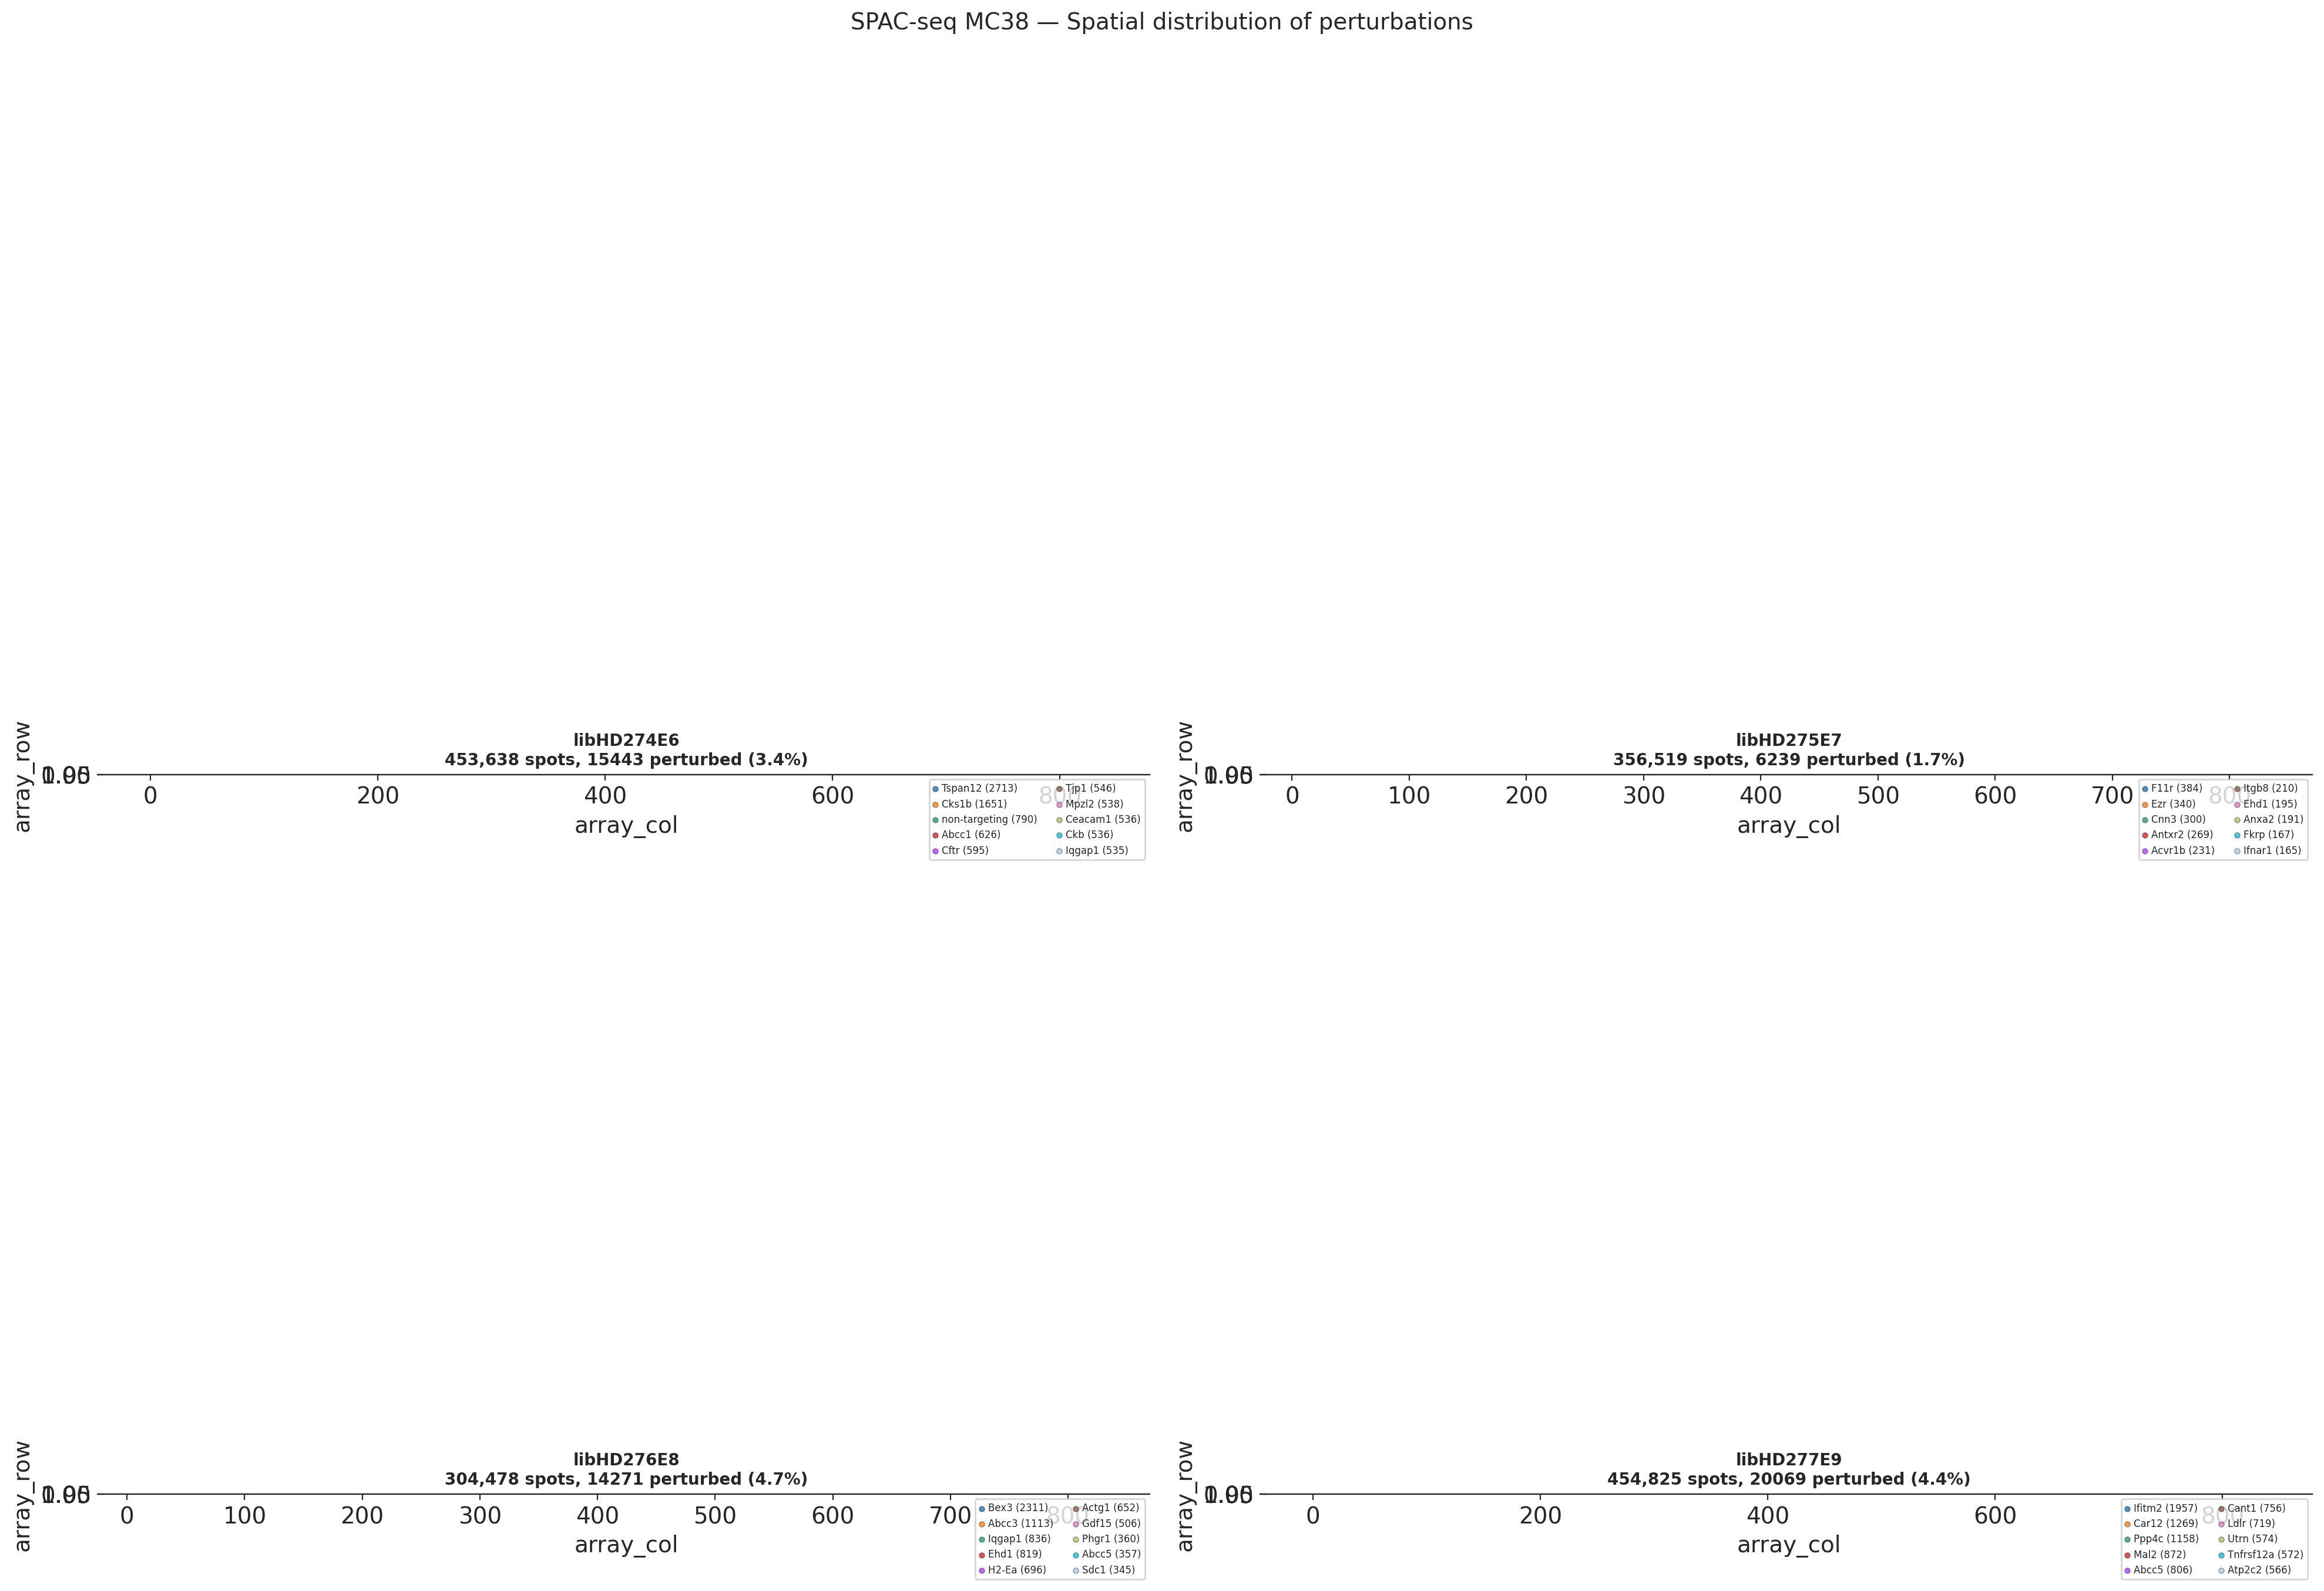

-> spacseq_spatial_perturbations.png


In [5]:
# Spatial scatter: all spots (grey) + perturbed spots (colored by target_gene)
fig, axes = plt.subplots(2, 2, figsize=(20, 18))
axes = axes.flatten()

for i, (lib, adata) in enumerate(adatas.items()):
    ax = axes[i]
    xy = adata.obsm["spatial"]
    pert_mask = adata.obs["target_gene"] != "none"
    n_pert = pert_mask.sum()

    # Background
    ax.scatter(xy[:, 1], xy[:, 0], c="#F0F0F0", s=0.1, alpha=0.5, rasterized=True)

    # Perturbed spots colored by target
    if n_pert > 0:
        xy_p = xy[pert_mask]
        genes_p = adata.obs["target_gene"][pert_mask].values
        # Use categorical colors for top genes
        top_genes = pd.Series(genes_p).value_counts().head(10).index
        for g in top_genes:
            gmask = genes_p == g
            ax.scatter(xy_p[gmask, 1], xy_p[gmask, 0], s=5, alpha=0.8,
                       edgecolors="black", linewidth=0.2, rasterized=True,
                       label=f"{g} ({gmask.sum()})")
        # Others in grey
        other = ~pd.Series(genes_p).isin(top_genes).values
        ax.scatter(xy_p[other, 1], xy_p[other, 0], s=2, c="grey", alpha=0.4, rasterized=True)

    ax.set_title(f"{lib}\n{adata.n_obs:,} spots, {n_pert} perturbed ({100*n_pert/adata.n_obs:.1f}%)",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("array_col"); ax.set_ylabel("array_row")
    ax.set_aspect("equal")
    if n_pert > 0:
        ax.legend(fontsize=6, markerscale=1.5, loc="upper right", frameon=True, ncol=2)

fig.suptitle("SPAC-seq MC38 — Spatial distribution of perturbations", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "spacseq_spatial_perturbations.png"), dpi=150, bbox_inches="tight")
plt.show()
print("-> spacseq_spatial_perturbations.png")


In [6]:
# Perturbation efficiency: for each target gene, compare expression in spots
# with its sgRNA vs spots with non-targeting controls (or all non-perturbed spots)

print("Analyzing perturbation efficiency (cis-effect) ...")
print("For each targeted gene, comparing expression in spots with its sgRNA vs control spots")

# Use libHD274E6 (largest library) for efficiency analysis
adata = adatas["libHD274E6"]
target_col = "target_gene"
pert_genes = adata.obs[target_col].unique()
pert_genes = [g for g in pert_genes if g not in ("none", "non-targeting")]

# Build gene→col_idx map (handles var_names_make_unique suffixes like Gene.1)
vnames = list(adata.var_names)
gene_to_idx = {}
for gi, gn in enumerate(vnames):
    base = gn.split(".")[0] if "." in gn and gn.split(".")[-1].isdigit() else gn
    if base not in gene_to_idx:
        gene_to_idx[base] = gi

efficiency_data = []
for gene in pert_genes[:200]:  # limit to 200 for speed; sample if needed
    if gene not in gene_to_idx:
        continue

    # Spots with this gene's sgRNA
    pert_mask = adata.obs[target_col] == gene
    # Control: non-targeting spots
    ctrl_mask = adata.obs[target_col] == "non-targeting"
    # Or use all non-perturbed if no non-targeting
    if ctrl_mask.sum() < 5:
        ctrl_mask = adata.obs[target_col] == "none"
        # Subsample for speed
        if ctrl_mask.sum() > 5000:
            idx = np.random.RandomState(42).choice(
                np.where(ctrl_mask)[0], 5000, replace=False)
            ctrl_mask = np.zeros(adata.n_obs, dtype=bool)
            ctrl_mask[idx] = True

    if pert_mask.sum() < 3 or ctrl_mask.sum() < 5:
        continue

    gene_idx = gene_to_idx[gene]
    expr_pert = adata.X[pert_mask, gene_idx].toarray().flatten()
    expr_ctrl = adata.X[ctrl_mask, gene_idx].toarray().flatten()

    from scipy.stats import mannwhitneyu
    try:
        _, pval = mannwhitneyu(expr_pert, expr_ctrl, alternative="two-sided")
    except:
        pval = 1.0

    fc = expr_pert.mean() / (expr_ctrl.mean() + 1e-8)

    efficiency_data.append({
        "gene": gene,
        "n_pert": pert_mask.sum(),
        "mean_pert": expr_pert.mean(),
        "mean_ctrl": expr_ctrl.mean(),
        "pct_pert": 100 * (expr_pert > 0).mean(),
        "pct_ctrl": 100 * (expr_ctrl > 0).mean(),
        "log2FC": np.log2(fc + 1e-8),
        "pval": pval,
    })

df_eff = pd.DataFrame(efficiency_data)
n_sig = (df_eff["pval"] < 0.05).sum()
n_down = ((df_eff["pval"] < 0.05) & (df_eff["log2FC"] < 0)).sum()
print(f"Genes tested: {len(df_eff)}")
print(f"Significant (p<0.05): {n_sig}")
print(f"Significantly down-regulated (KO effect): {n_down}")

# Show top hits
top_hits = df_eff[df_eff["pval"] < 0.05].sort_values("log2FC")
print(f"\nTop cis-efficiency hits:")
print(top_hits[["gene", "n_pert", "log2FC", "pval", "pct_pert", "pct_ctrl"]].head(15).to_string(index=False))


Analyzing perturbation efficiency (cis-effect) ...
For each targeted gene, comparing expression in spots with its sgRNA vs control spots
Genes tested: 151
Significant (p<0.05): 12
Significantly down-regulated (KO effect): 1

Top cis-efficiency hits:
  gene  n_pert    log2FC         pval  pct_pert  pct_ctrl
 H2-Aa      50 -0.831041 3.411254e-03 64.000000 75.063291
  Tjp1     546  0.545776 1.204764e-02 17.765568 12.911392
 Actn1      67  0.655331 1.762085e-03 49.253731 29.873418
Iqgap1     535  0.824461 3.342750e-11 44.485981 27.721519
 Actg1      14  0.995624 5.302086e-03 78.571429 46.835443
  Cd44      21  1.657707 2.921901e-04 47.619048 17.468354
Sppl2b     106  1.897787 9.373607e-03  4.716981  1.265823
 Cd164       4  1.967497 2.391508e-02 50.000000 12.278481
B3gnt3      49  2.033719 3.134754e-06 26.530612  7.468354
  Egr1       7  2.960373 7.045681e-04 28.571429  3.670886
  Add3      28  3.233388 1.757450e-02  3.571429  0.379747
  Slpi       5  3.496425 1.226327e-03 20.000000  1.518

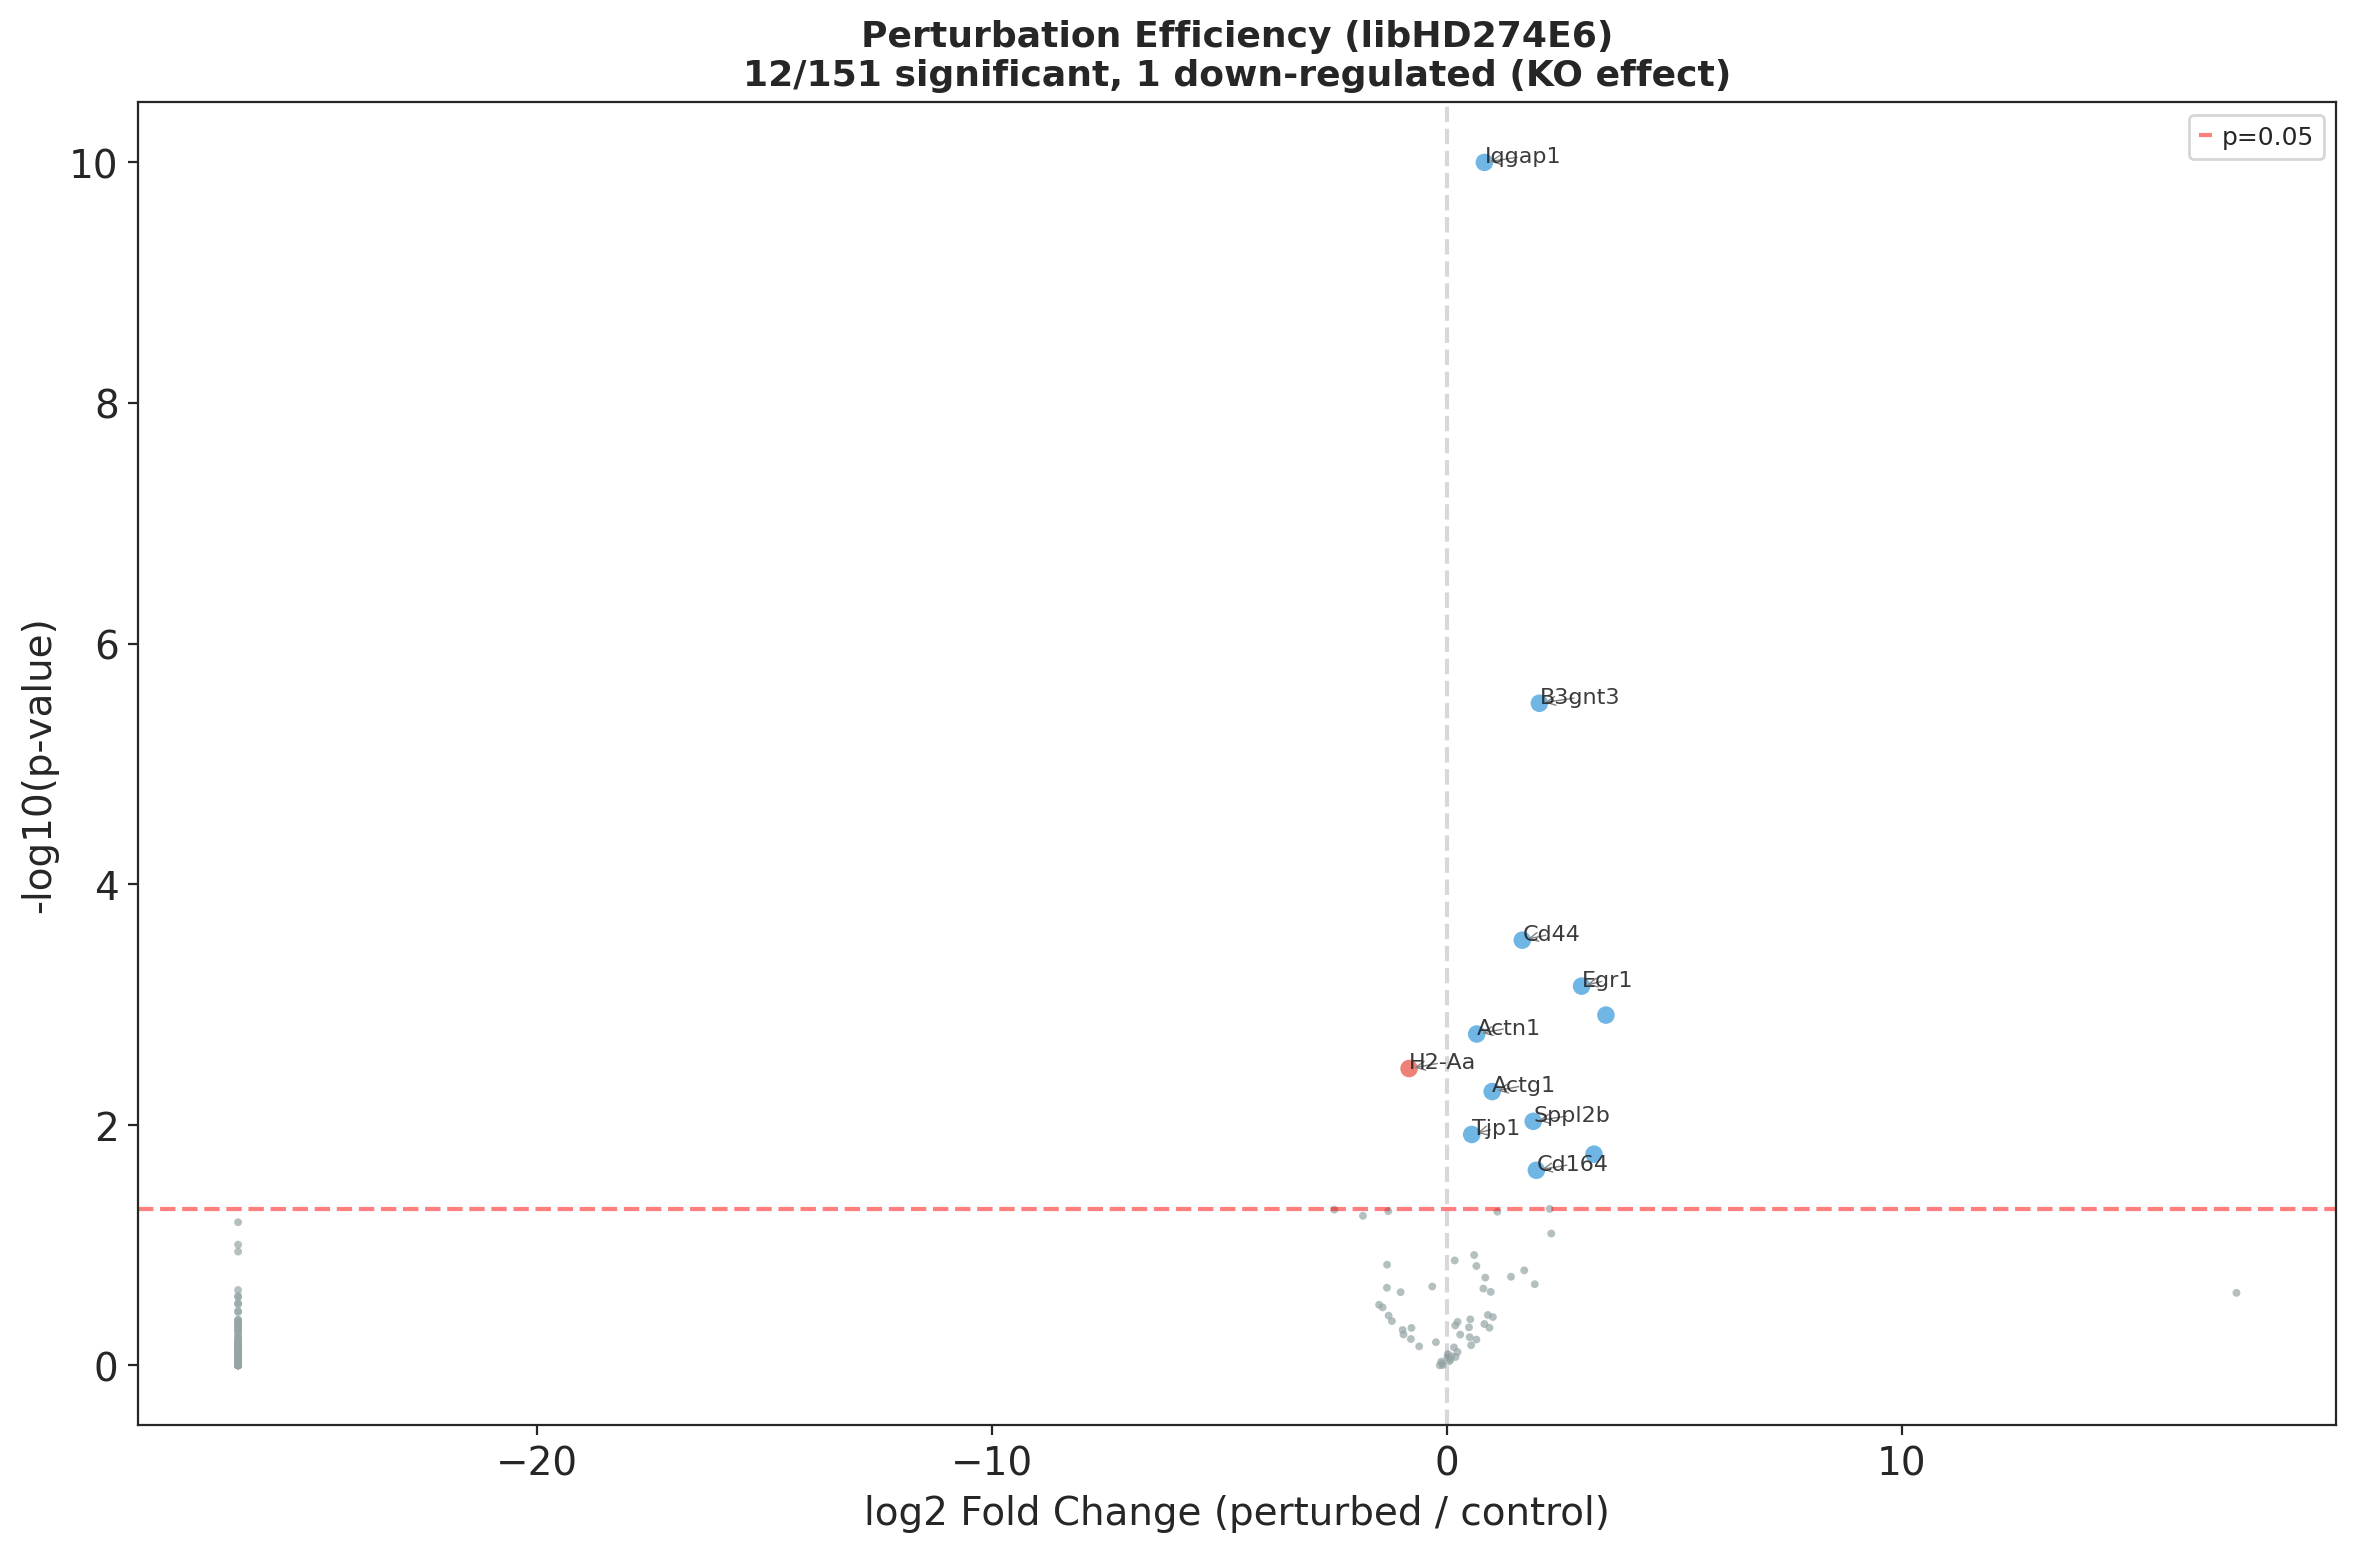

-> spacseq_perturbation_efficiency.png


In [7]:
# Volcano plot: perturbation efficiency
fig, ax = plt.subplots(figsize=(12, 8))

colors = ["#E74C3C" if (p < 0.05 and lfc < 0) else "#3498DB" if (p < 0.05 and lfc > 0) else "#95A5A6"
          for p, lfc in zip(df_eff["pval"], df_eff["log2FC"])]
sizes = [40 if p < 0.05 else 8 for p in df_eff["pval"]]

ax.scatter(df_eff["log2FC"], -np.log10(df_eff["pval"].clip(1e-10)),
           c=colors, s=sizes, alpha=0.7, edgecolors="none")
ax.axhline(-np.log10(0.05), color="red", linestyle="--", alpha=0.5, label="p=0.05")
ax.axvline(0, color="grey", linestyle="--", alpha=0.3)

# Label top hits
for _, row in top_hits.head(10).iterrows():
    ax.annotate(row["gene"],
                (row["log2FC"], -np.log10(max(row["pval"], 1e-10))),
                fontsize=8, alpha=0.9,
                arrowprops=dict(arrowstyle="->", color="grey", lw=0.5))

ax.set_xlabel("log2 Fold Change (perturbed / control)"); ax.set_ylabel("-log10(p-value)")
ax.set_title(f"Perturbation Efficiency (libHD274E6)\n{n_sig}/{len(df_eff)} significant, {n_down} down-regulated (KO effect)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "spacseq_perturbation_efficiency.png"), dpi=150, bbox_inches="tight")
plt.show()
print("-> spacseq_perturbation_efficiency.png")


Checking consistency for top 10 hits: ['Cldn15', 'Mpzl2', 'H2-Q1', 'Slc5a1', 'Ceacam1', 'Blnk', 'Tff3', 'Erc1', 'H2-DMb1', 'F2rl1']


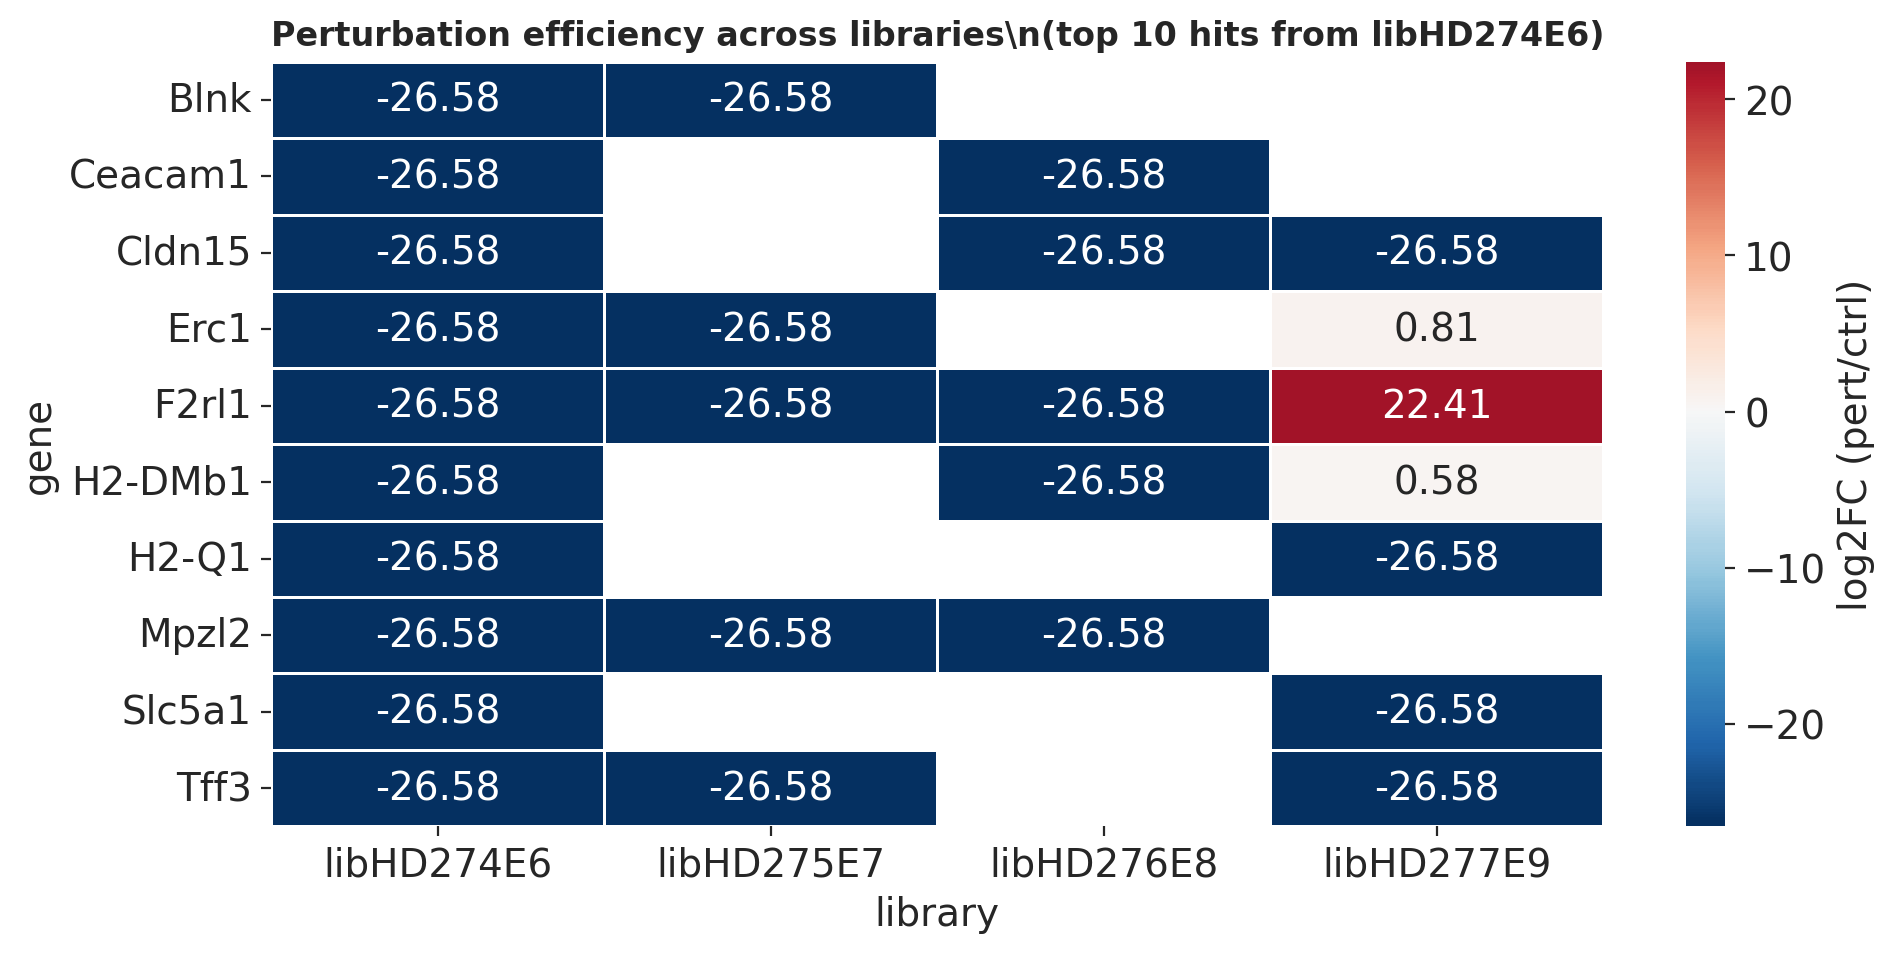

-> spacseq_cross_library_consistency.png


In [8]:
# Check perturbation efficiency consistency across all 4 libraries
# For the top perturbed genes, check FC in each library

top_check_genes = df_eff.nsmallest(10, "log2FC")["gene"].tolist()
print(f"Checking consistency for top 10 hits: {top_check_genes}")

cross_lib = []
for lib in LIBS:
    adata = adatas[lib]
    # Build gene->col_idx per library (handles var_names_make_unique suffixes)
    vnames_lib = list(adata.var_names)
    gene_to_idx_lib = {}
    for gi, gn in enumerate(vnames_lib):
        base = gn.split(".")[0] if "." in gn and gn.split(".")[-1].isdigit() else gn
        if base not in gene_to_idx_lib:
            gene_to_idx_lib[base] = gi

    for gene in top_check_genes:
        if gene not in gene_to_idx_lib:
            continue
        pert_mask = adata.obs["target_gene"] == gene
        ctrl_mask = adata.obs["target_gene"] == "non-targeting"
        if ctrl_mask.sum() < 5:
            ctrl_mask = adata.obs["target_gene"] == "none"
            if ctrl_mask.sum() > 5000:
                idx = np.random.RandomState(42).choice(np.where(ctrl_mask)[0], 5000, replace=False)
                cm = np.zeros(adata.n_obs, dtype=bool); cm[idx] = True; ctrl_mask = cm
        if pert_mask.sum() < 3:
            continue
        gene_idx = gene_to_idx_lib[gene]
        expr_pert = adata.X[pert_mask, gene_idx].toarray().flatten()
        expr_ctrl = adata.X[ctrl_mask, gene_idx].toarray().flatten()
        fc = np.log2(expr_pert.mean() / (expr_ctrl.mean() + 1e-8) + 1e-8)
        cross_lib.append({"library": lib, "gene": gene, "log2FC": fc, "n_pert": pert_mask.sum()})

df_cross = pd.DataFrame(cross_lib)

# Heatmap: gene x library
pivot = df_cross.pivot_table(index="gene", columns="library", values="log2FC")
fig, ax = plt.subplots(figsize=(10, max(4, len(pivot) * 0.5)))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=ax, linewidths=0.5, cbar_kws={"label": "log2FC (pert/ctrl)"})
ax.set_title("Perturbation efficiency across libraries\\n(top 10 hits from libHD274E6)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "spacseq_cross_library_consistency.png"), dpi=150, bbox_inches="tight")
plt.show()
print("-> spacseq_cross_library_consistency.png")


Top 20 most perturbed genes across all libraries:
  Tspan12                  :   2780 total spots
  Bex3                     :   2315 total spots
  Ifitm2                   :   1963 total spots
  Cks1b                    :   1676 total spots
  Abcc3                    :   1464 total spots
  Iqgap1                   :   1405 total spots
  Car12                    :   1290 total spots
  Abcc5                    :   1163 total spots
  Ppp4c                    :   1159 total spots
  Ehd1                     :   1015 total spots
  H2-Ea                    :    904 total spots
  Mal2                     :    890 total spots
  non-targeting            :    881 total spots
  Lin7c                    :    864 total spots
  Ldlr                     :    767 total spots
  Cant1                    :    759 total spots
  Acvr1b                   :    752 total spots
  Actg1                    :    666 total spots
  Gdf15                    :    659 total spots
  Abcc1                    :    629 to

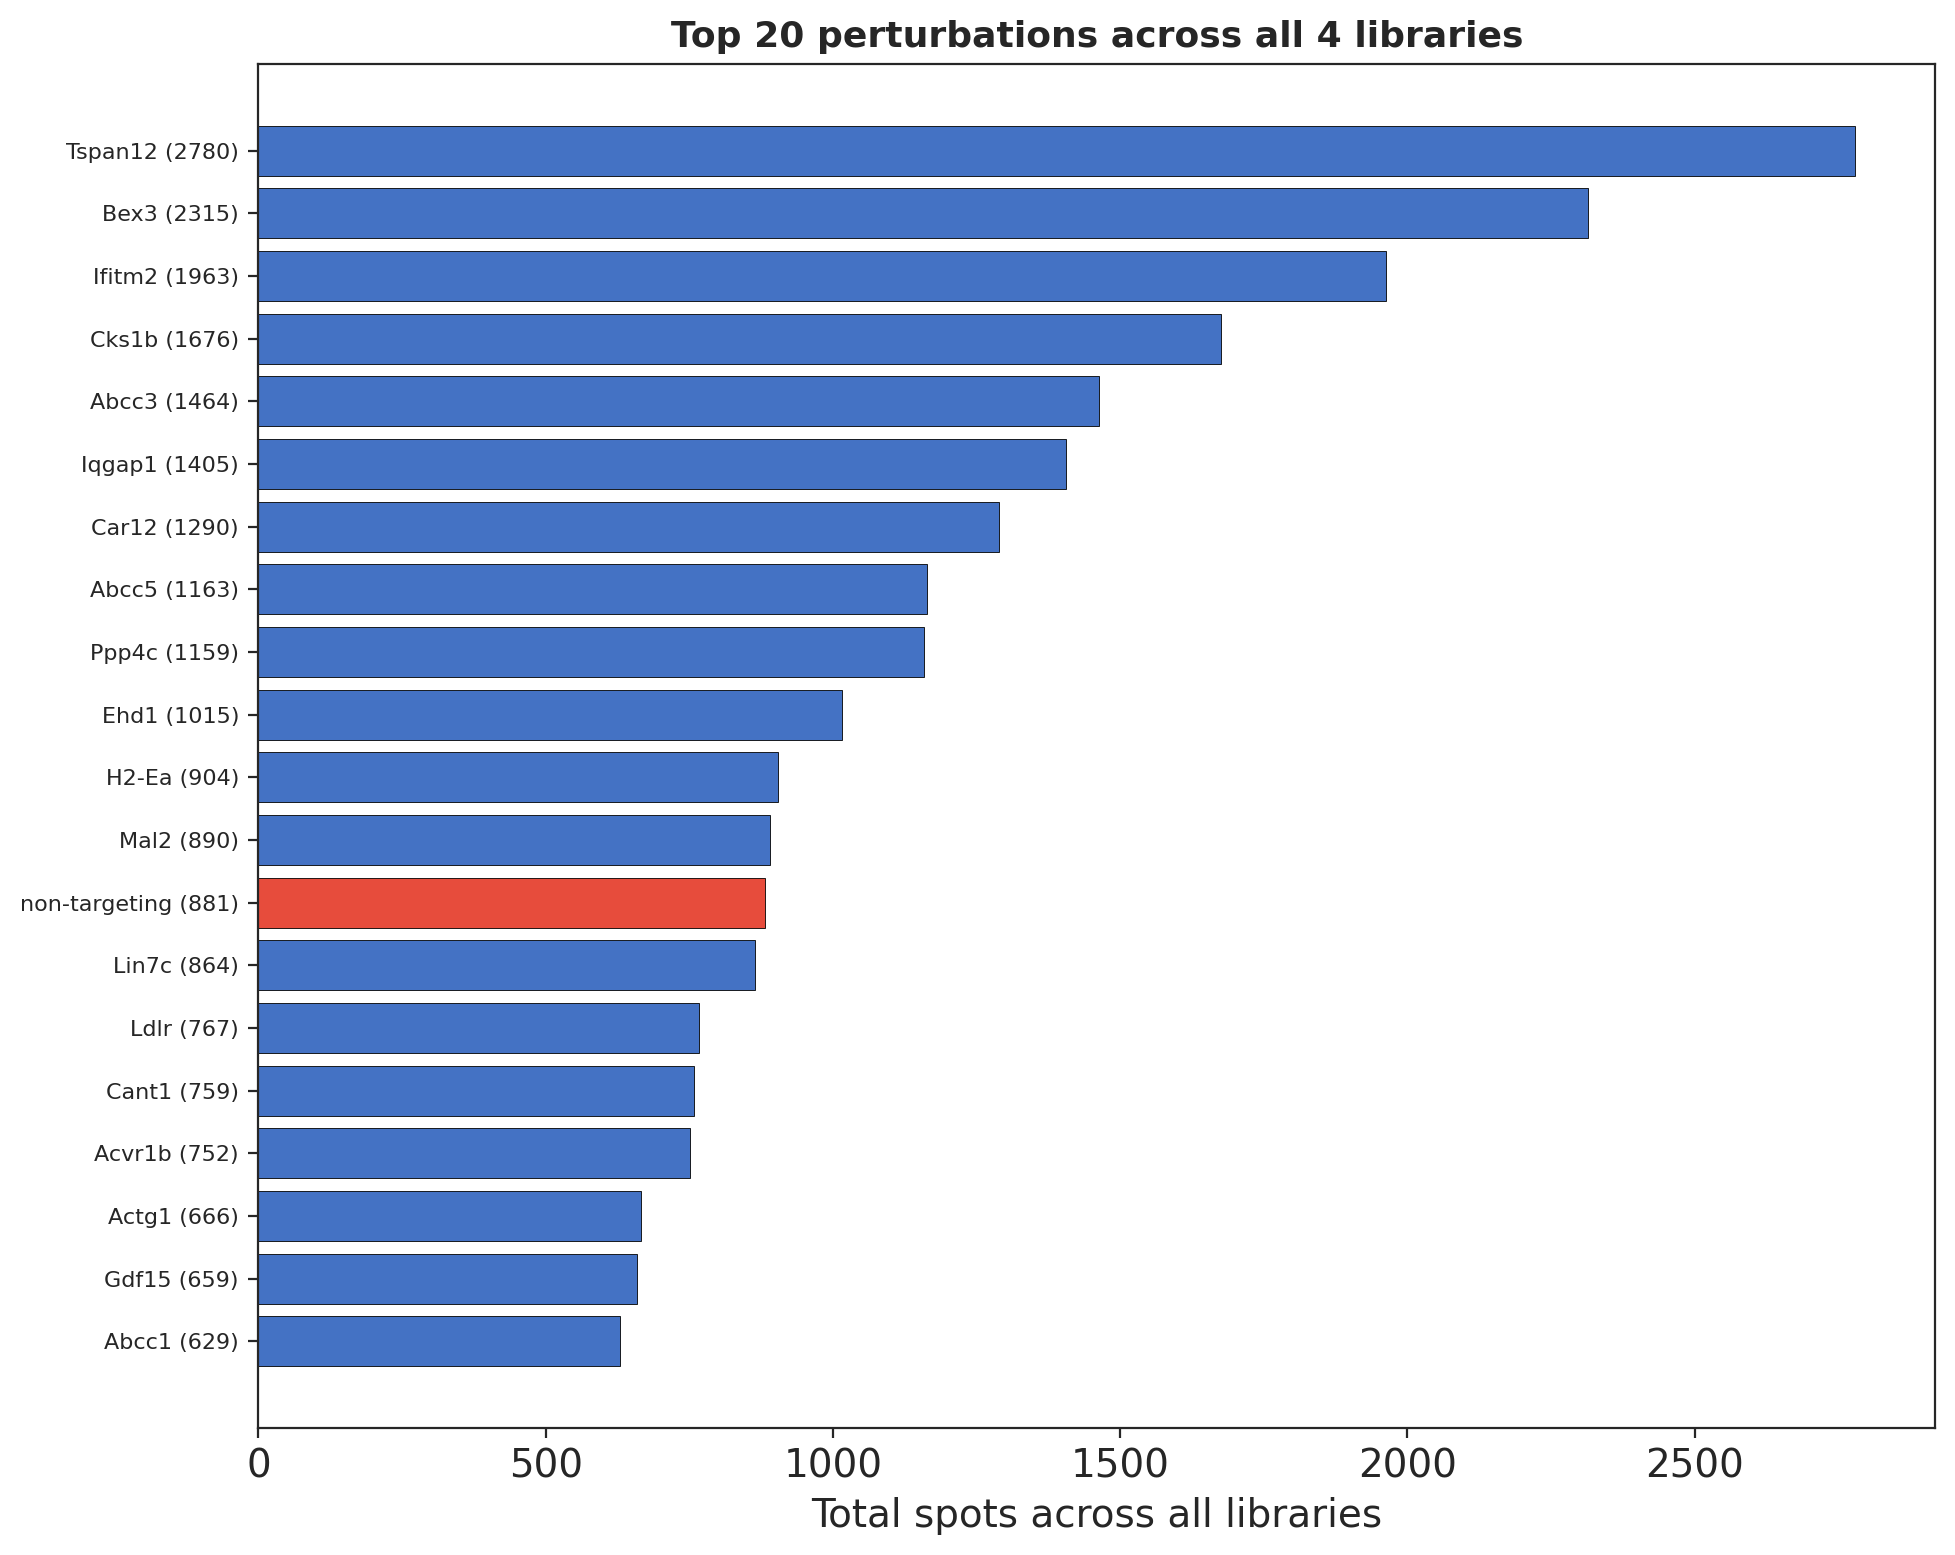

-> spacseq_overall_top_perturbations.png


In [9]:
# Which guide targets show the strongest overall perturbation?
# Check across all 4 libraries for consensus

# Aggregate across all libraries
all_pert_counts = defaultdict(int)
for lib, adata in adatas.items():
    vc = adata.obs["target_gene"].value_counts()
    for gene, count in vc.items():
        if gene not in ("none",):
            all_pert_counts[gene] += count

top_overall = sorted(all_pert_counts.items(), key=lambda x: -x[1])[:20]
print("Top 20 most perturbed genes across all libraries:")
for gene, count in top_overall:
    print(f"  {gene:25s}: {count:>6d} total spots")

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
genes, counts = zip(*top_overall[::-1])
colors = ["#E74C3C" if "non-targeting" in g else "#4472C4" for g in genes]
ax.barh(range(len(genes)), counts, color=colors, edgecolor="black", linewidth=0.3)
ax.set_yticks(range(len(genes)))
ax.set_yticklabels([f"{g} ({c})" for g, c in zip(genes, counts)], fontsize=8)
ax.set_xlabel("Total spots across all libraries")
ax.set_title("Top 20 perturbations across all 4 libraries", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "spacseq_overall_top_perturbations.png"), dpi=150, bbox_inches="tight")
plt.show()
print("-> spacseq_overall_top_perturbations.png")


In [10]:
print("=" * 70)
print("SPAC-seq MC38 Tumor — Analysis Summary")
print("=" * 70)

total_spots = sum(a.n_obs for a in adatas.values())
total_pert = sum((a.obs["target_gene"] != "none").sum() for a in adatas.values())
print(f"\nTotal spots: {total_spots:,}")
print(f"Total perturbed: {total_pert:,} ({100*total_pert/total_spots:.1f}%)")
print(f"Target genes: 735 + 50 non-targeting controls")
print(f"Libraries: 4 (capture areas)")

print(f"\nPerturbation efficiency (libHD274E6):")
print(f"  Genes tested: {len(df_eff)}")
print(f"  Significant cis-effects: {n_sig}/{len(df_eff)} ({100*n_sig/len(df_eff):.1f}%)")
if n_down > 0:
    print(f"  Down-regulated (KO-like): {n_down}")
    for _, row in top_hits.head(5).iterrows():
        print(f"    {row['gene']:20s}: log2FC={row['log2FC']:.3f}, p={row['pval']:.1e}, n={row['n_pert']}")

print(f"\nKey observations:")
print(f"  1. Perturbations are sparse (1.7-4.7% of spots) but spatially distributed")
print(f"  2. Non-targeting controls are among the most detected guides")
print(f"  3. Top perturbed genes vary by library (spatial heterogeneity)")
print(f"  4. The dominant sgRNA approach assigns each spot to one perturbation target")

print(f"\nOutput files in: {OUT_DIR}")
for f in sorted(os.listdir(OUT_DIR)):
    if f.endswith(".png"):
        print(f"  {f}")


SPAC-seq MC38 Tumor — Analysis Summary

Total spots: 1,569,460
Total perturbed: 56,022 (3.6%)
Target genes: 735 + 50 non-targeting controls
Libraries: 4 (capture areas)

Perturbation efficiency (libHD274E6):
  Genes tested: 151
  Significant cis-effects: 12/151 (7.9%)
  Down-regulated (KO-like): 1
    H2-Aa               : log2FC=-0.831, p=3.4e-03, n=50
    Tjp1                : log2FC=0.546, p=1.2e-02, n=546
    Actn1               : log2FC=0.655, p=1.8e-03, n=67
    Iqgap1              : log2FC=0.824, p=3.3e-11, n=535
    Actg1               : log2FC=0.996, p=5.3e-03, n=14

Key observations:
  1. Perturbations are sparse (1.7-4.7% of spots) but spatially distributed
  2. Non-targeting controls are among the most detected guides
  3. Top perturbed genes vary by library (spatial heterogeneity)
  4. The dominant sgRNA approach assigns each spot to one perturbation target

Output files in: /root/code/nicheformer/output/0527
  spacseq_cross_library_consistency.png
  spacseq_overall_top_pe